In [2]:
import xarray as xr
import matplotlib.pyplot as plt

In [3]:
bioSoil_cube = xr.open_dataset("bioSoil_techdemo/openEO.nc", engine="netcdf4")
bioSoil_cube

<xarray.Dataset> Size: 12MB
Dimensions:  (t: 12, x: 145, y: 139)
Coordinates:
  * t        (t) datetime64[ns] 96B 2019-01-01 2019-02-01 ... 2019-12-01
  * x        (x) float64 1kB 3.903e+05 3.913e+05 ... 5.333e+05 5.343e+05
  * y        (y) float64 1kB 6.702e+06 6.701e+06 6.7e+06 ... 6.565e+06 6.564e+06
Data variables: (12/13)
    crs      |S1 1B ...
    NDVI     (t, y, x) float32 967kB ...
    EVI      (t, y, x) float32 967kB ...
    MSAVI    (t, y, x) float32 967kB ...
    NDRE     (t, y, x) float32 967kB ...
    REIP     (t, y, x) float32 967kB ...
    ...       ...
    CRI      (t, y, x) float32 967kB ...
    NDWI     (t, y, x) float32 967kB ...
    NDMI     (t, y, x) float32 967kB ...
    NBR      (t, y, x) float32 967kB ...
    FPAR     (t, y, x) float32 967kB ...
    NDLI     (t, y, x) float32 967kB ...
Attributes:
    Conventions:  CF-1.9
    institution:  Copernicus Data Space Ecosystem openEO API - 0.70.0a7.dev20...
    description:  
    title:

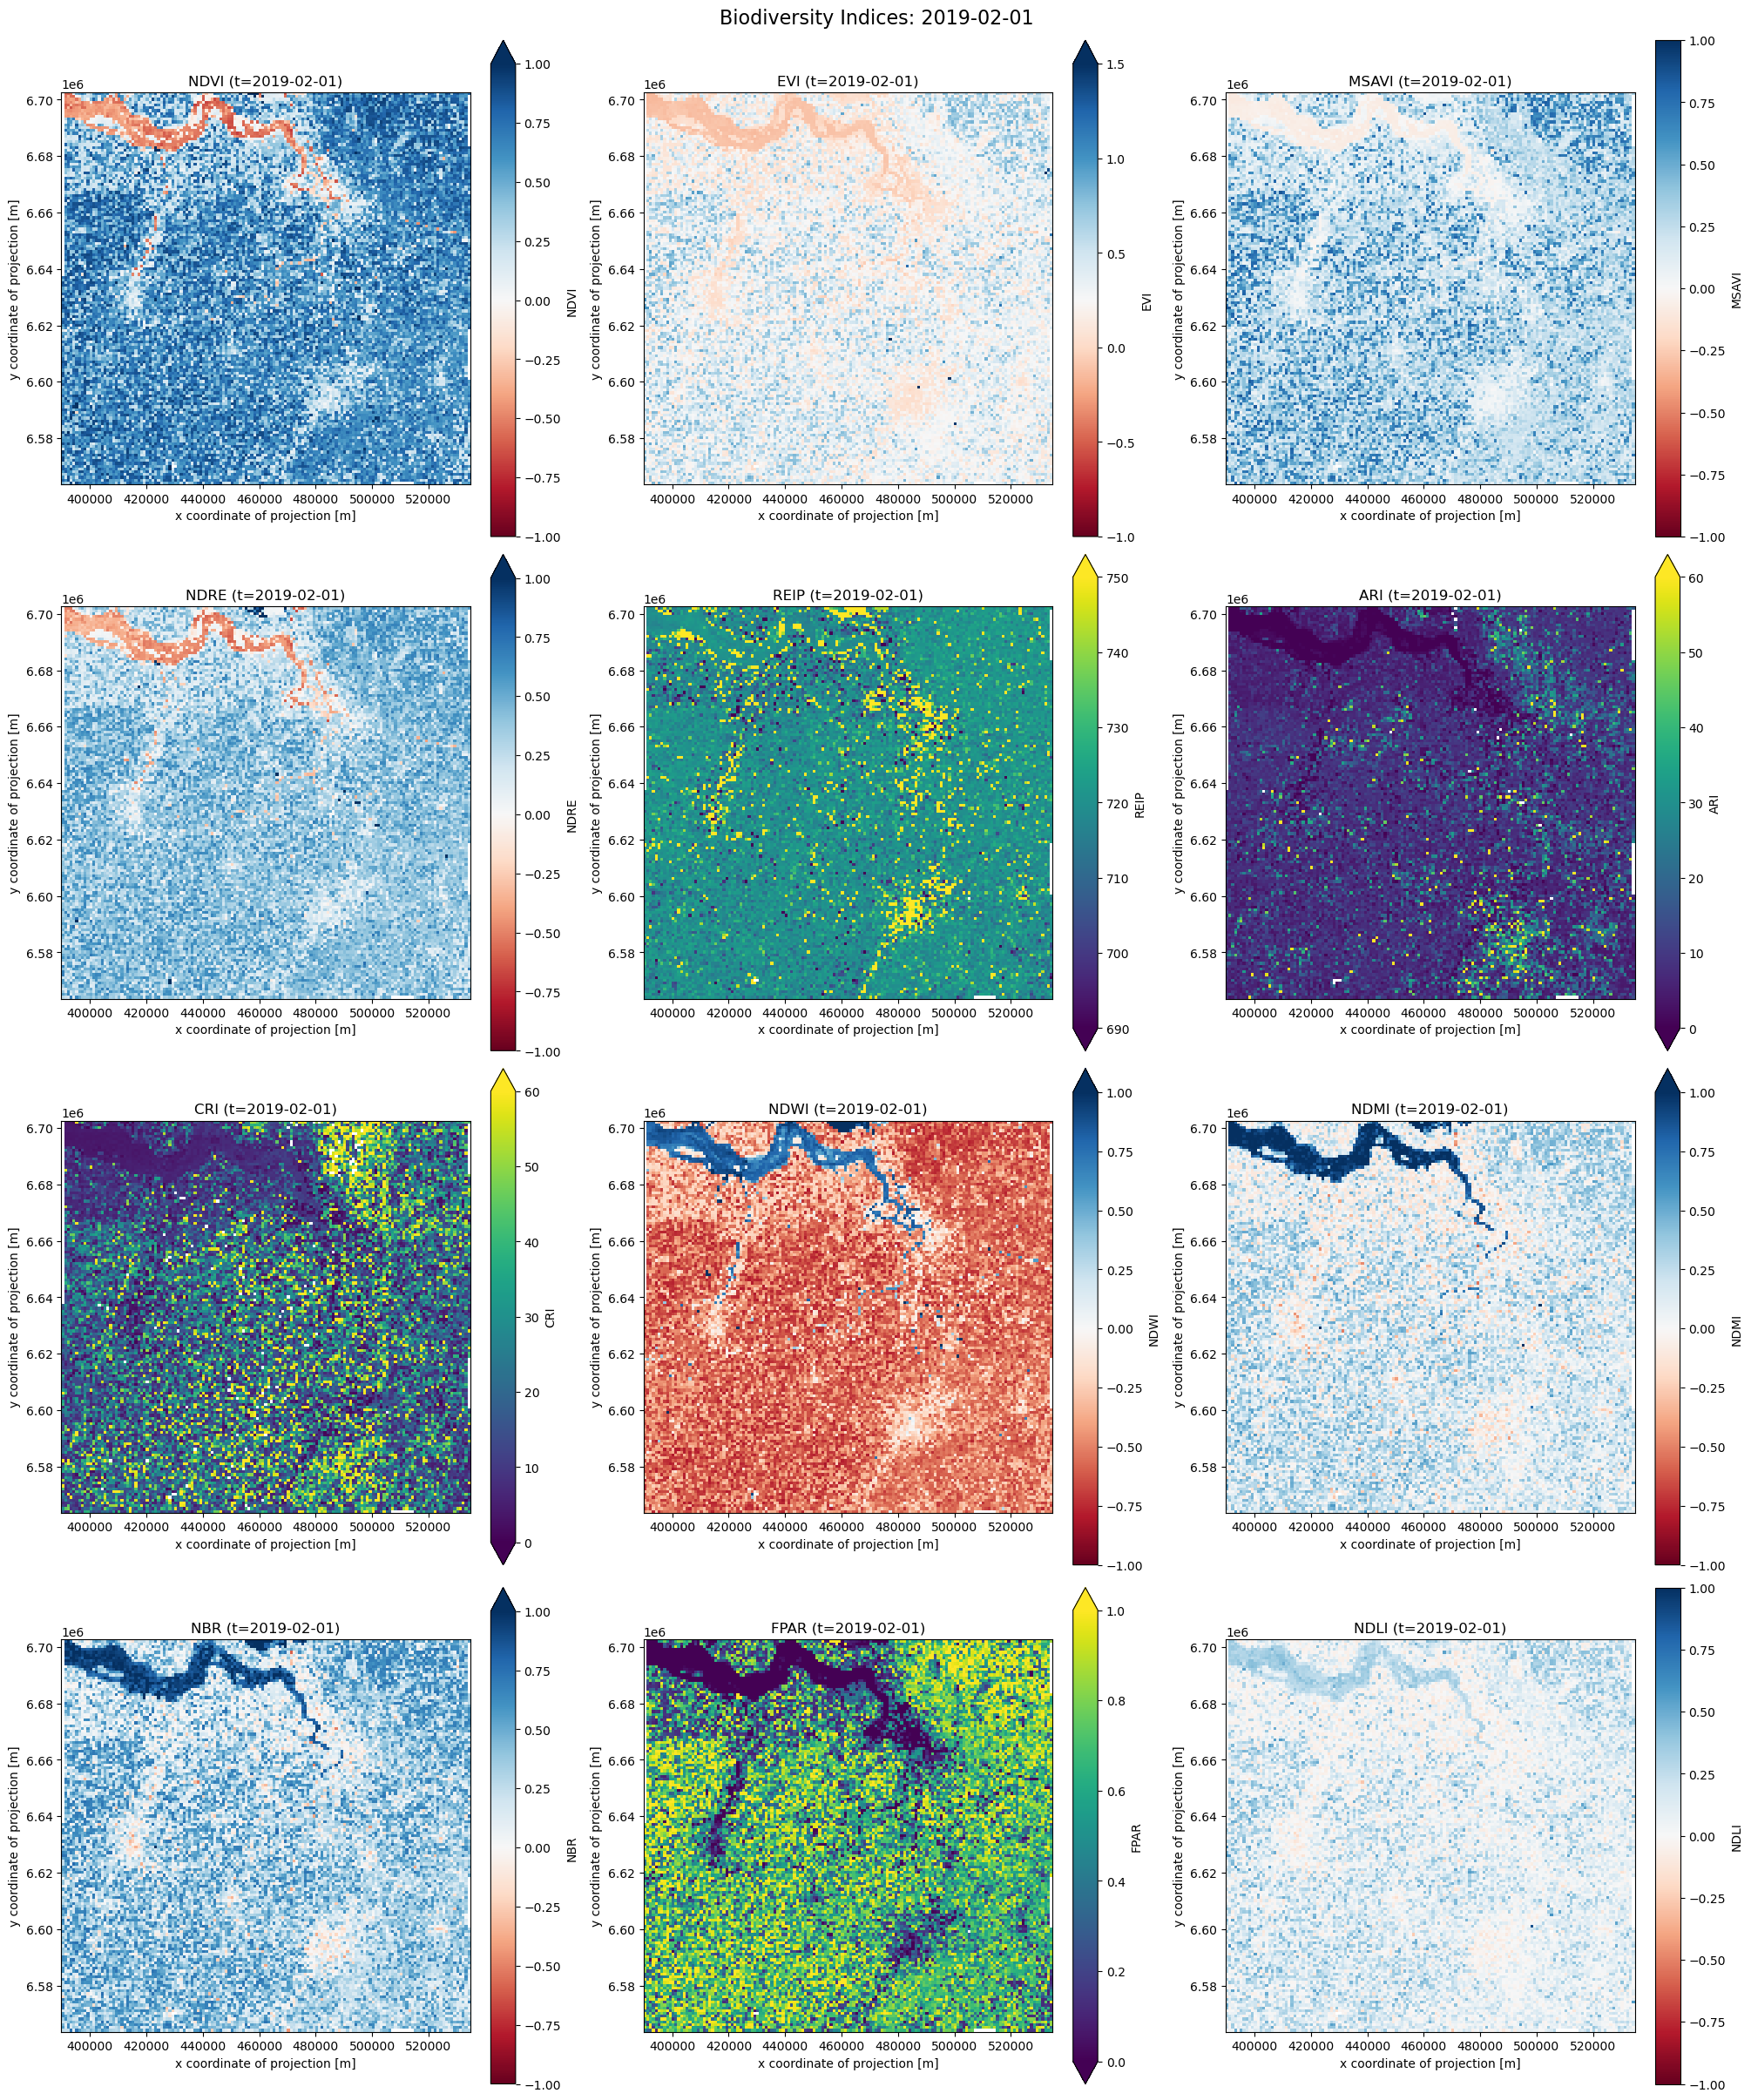

In [11]:
import math

# 1. Define your valid ranges (from your snippet)
valid_ranges = {
    "NDVI":  (-1.0, 1.0),
    "NDRE":  (-1.0, 1.0),
    "NDWI":  (-1.0, 1.0),
    "NDMI":  (-1.0, 1.0),
    "NBR":   (-1.0, 1.0),
    "NDLI":  (-1.0, 1.0),
    "EVI":   (-1.0, 1.5),
    "MSAVI": (-1.0, 1.0),
    "FPAR":  (0.0, 1.0),
    "REIP":  (690, 750),    # Correct physical range for wavelengths
    "ARI":   (0, 60),      # Adjusted max to 0.2 for better visual contrast (1.0 is often too high for ARI)
    "CRI":   (0, 60)       # Adjusted max to 0.2 for better visual contrast
}

# 2. Select the second month (index 1)
# Assuming your dataset variable is named 'bio_master_cube' or similar
# If you loaded it from NetCDF, it might be 'ds'
month_data = bioSoil_cube.isel(t=1) 

# 3. Get list of actual data variables (excluding 'crs' if present)
plot_vars = [v for v in month_data.data_vars if v != "crs"]
num_plots = len(plot_vars)

# 4. Calculate grid size (e.g., 3 columns wide)
cols = 3
rows = math.ceil(num_plots / cols)

# 5. Create the figure
fig, axes = plt.subplots(rows, cols, figsize=(20, 6 * rows), constrained_layout=True)
axes = axes.flatten()

# 6. Loop through variables and plot
for i, var_name in enumerate(plot_vars):
    ax = axes[i]
    da = month_data[var_name]
    
    # Determine limits
    if var_name in valid_ranges:
        vmin, vmax = valid_ranges[var_name]
    else:
        # Fallback if a variable isn't in your dict
        vmin, vmax = None, None
        
    # Plot using Xarray's wrapper
    # we use a diverging colormap ('RdBu') for indices centered on 0, 
    # and 'viridis' for absolute values like REIP/ARI
    cmap = "viridis" 
    if vmin is not None and vmin < 0:
        cmap = "RdBu"
        
    im = da.plot(
        ax=ax, 
        vmin=vmin, 
        vmax=vmax, 
        cmap=cmap,
        add_colorbar=True,
        cbar_kwargs={"label": var_name} # specific label for the bar
    )
    
    ax.set_title(f"{var_name} (t={str(da.t.values)[:10]})")
    ax.set_aspect("equal")

# 7. Hide empty subplots if any
for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.suptitle(f"Biodiversity Indices: {str(month_data.t.values)[:10]}", fontsize=16)
plt.savefig("bioIndex_example.png")

In [16]:
import math
import matplotlib.pyplot as plt

# 1. Define your valid ranges
valid_ranges = {
    "NDVI":  (-1.0, 1.0),
    "NDRE":  (-1.0, 1.0),
    "NDWI":  (-1.0, 1.0),
    "NDMI":  (-1.0, 1.0),
    "NBR":   (-1.0, 1.0),
    "NDLI":  (-1.0, 1.0),
    "EVI":   (-1.0, 1.5),
    "MSAVI": (-1.0, 1.0),
    "FPAR":  (0.0, 1.0),
    "REIP":  (690, 750),
    "ARI":   (0, 60),
    "CRI":   (0, 60)
}

# 2. Select the data
month_data = bioSoil_cube.isel(t=1) 
plot_vars = [v for v in month_data.data_vars if v != "crs"]

# 3. Define Batch Size
batch_size = 6
total_batches = math.ceil(len(plot_vars) / batch_size)

# 4. Loop through chunks of variables
for batch_idx in range(total_batches):
    # Slice the list to get only the next 6 variables
    start_i = batch_idx * batch_size
    end_i = start_i + batch_size
    current_batch = plot_vars[start_i:end_i]
    
    # Calculate grid for THIS batch
    num_plots = len(current_batch)
    cols = 3
    rows = math.ceil(num_plots / cols)
    
    # Create the figure for this batch
    fig, axes = plt.subplots(rows, cols, figsize=(20, 6 * rows), constrained_layout=True)
    
    # Ensure axes is always a list (even if only 1 row)
    if rows * cols == 1:
        axes = [axes]
    else:
        axes = axes.flatten()
    
    # Loop through the current batch of variables
    for i, var_name in enumerate(current_batch):
        ax = axes[i]
        da = month_data[var_name]
        
        # Determine limits
        if var_name in valid_ranges:
            vmin, vmax = valid_ranges[var_name]
        else:
            vmin, vmax = None, None
            
        # Determine colormap
        cmap = "viridis" 
        if vmin is not None and vmin < 0:
            cmap = "RdBu"
            
        # Plot
        im = da.plot(
            ax=ax, 
            vmin=vmin, 
            vmax=vmax, 
            cmap=cmap,
            add_colorbar=True,
            cbar_kwargs={"label": var_name}
        )
        
        ax.set_title(f"{var_name} (t={str(da.t.values)[:10]})")
        ax.set_aspect("equal")
    
    # Hide empty subplots in this batch
    for j in range(i + 1, len(axes)):
        axes[j].axis("off")
    
    # Add Title and Save
    part_num = batch_idx + 1
    plt.suptitle(f"Biodiversity Indices (Part {part_num}): {str(month_data.t.values)[:10]}", fontsize=16)
    
    filename = f"bioIndex_example_part{part_num}.png"
    plt.savefig(filename)
    print(f"Saved {filename}")
    plt.close(fig) # Close to free up memory

Saved bioIndex_example_part1.png
Saved bioIndex_example_part2.png


In [8]:
print(bioSoil_cube.isel(t=1)["ARI"].max().values)
print(bioSoil_cube.isel(t=1)["CRI"].max().values)

85.88582611083984
81.79610443115234


In [12]:
landcover_ds = xr.open_dataset('fracLandCover_techdemo/openEO.nc', engine="netcdf4")
topo_ds = xr.open_dataset('topographic_techdemo/openEO.nc', engine="netcdf4")

C:\Users\niels\AppData\Local\Temp\ipykernel_34800\385997098.py:29: DeprecationWarning: self.axes is deprecated since 2022.11 in order to align with matplotlibs plt.subplots, use self.axs instead.
  for ax in g.axes.flat:


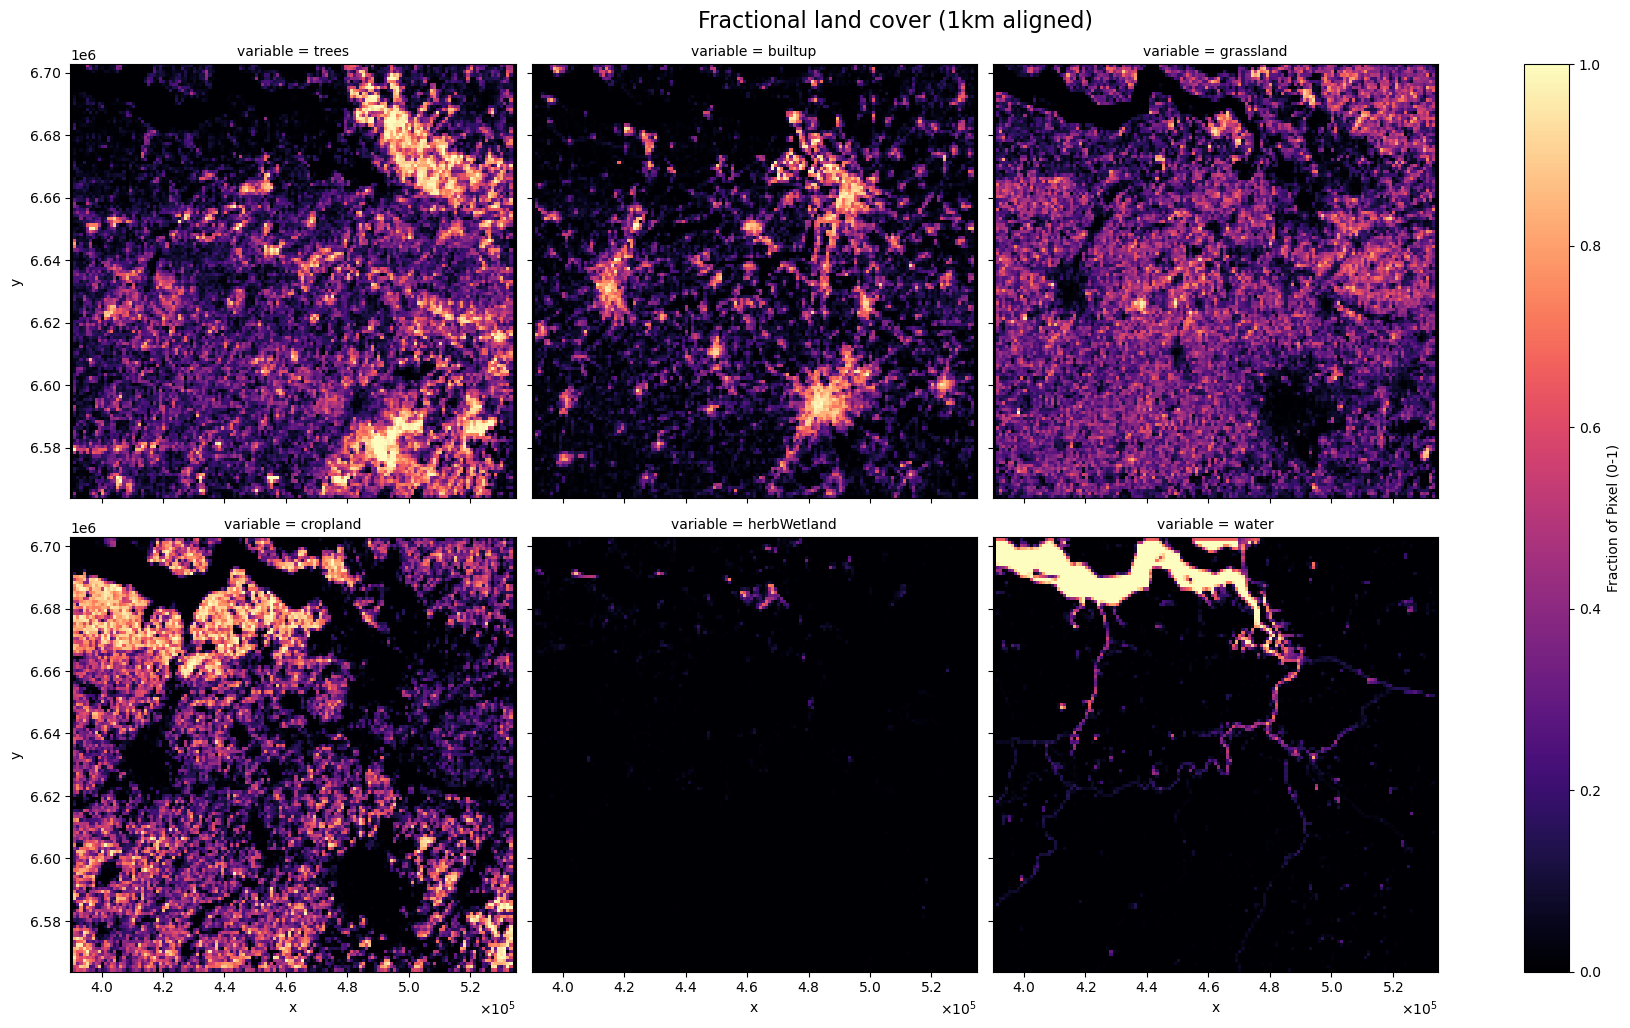

In [17]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

# 1. Select the first time step
ds_2d = landcover_ds.isel(t=0)

# 2. Define your specific classes
target_classes = ["trees", "builtup", "grassland", "cropland", "herbWetland", "water"]

# Filter the dataset to include ONLY these classes
# We add a check `if var in ds_2d` to prevent errors if a class name is slightly mismatched
selected_vars = [var for var in target_classes if var in ds_2d.data_vars]
ds_filtered = ds_2d[selected_vars]

# ==============================================================================
# PLOT: FRACTION GRID (Specific Classes)
# ==============================================================================
g = ds_filtered.to_array().plot(
    col="variable", 
    col_wrap=3,       # 3 columns x 2 rows = perfect for 6 classes
    cmap="magma", 
    vmin=0, vmax=1, 
    figsize=(18, 10), # Adjusted size for 6 subplots
    cbar_kwargs={"label": "Fraction of Pixel (0-1)"}
)

# --- SCIENTIFIC NOTATION ON X-AXIS ---
for ax in g.axes.flat:
    ax.xaxis.set_major_formatter(ticker.ScalarFormatter(useMathText=True))
    ax.ticklabel_format(style='sci', axis='x', scilimits=(0,0))

plt.suptitle("Fractional land cover (1km aligned)", fontsize=16, y=1.02)
plt.savefig("landcover_fractions.png")
plt.show()

In [24]:
topo_ds

<xarray.Dataset> Size: 2MB
Dimensions:     (x: 211, y: 245)
Coordinates:
  * x           (x) float64 2kB 3.572e+05 3.582e+05 ... 5.662e+05 5.672e+05
  * y           (y) float64 2kB 6.756e+06 6.755e+06 ... 6.513e+06 6.512e+06
Data variables:
    crs         |S1 1B ...
    elevation   (y, x) float64 414kB ...
    slope       (y, x) float64 414kB ...
    curvature   (y, x) float64 414kB ...
    northness   (y, x) float64 414kB ...
    eastness    (y, x) float64 414kB ...
    ruggedness  (y, x) float64 414kB ...
Attributes:
    Conventions:  CF-1.9
    institution:  Copernicus Data Space Ecosystem openEO API - 0.70.0a7.dev20...
    description:  
    title:

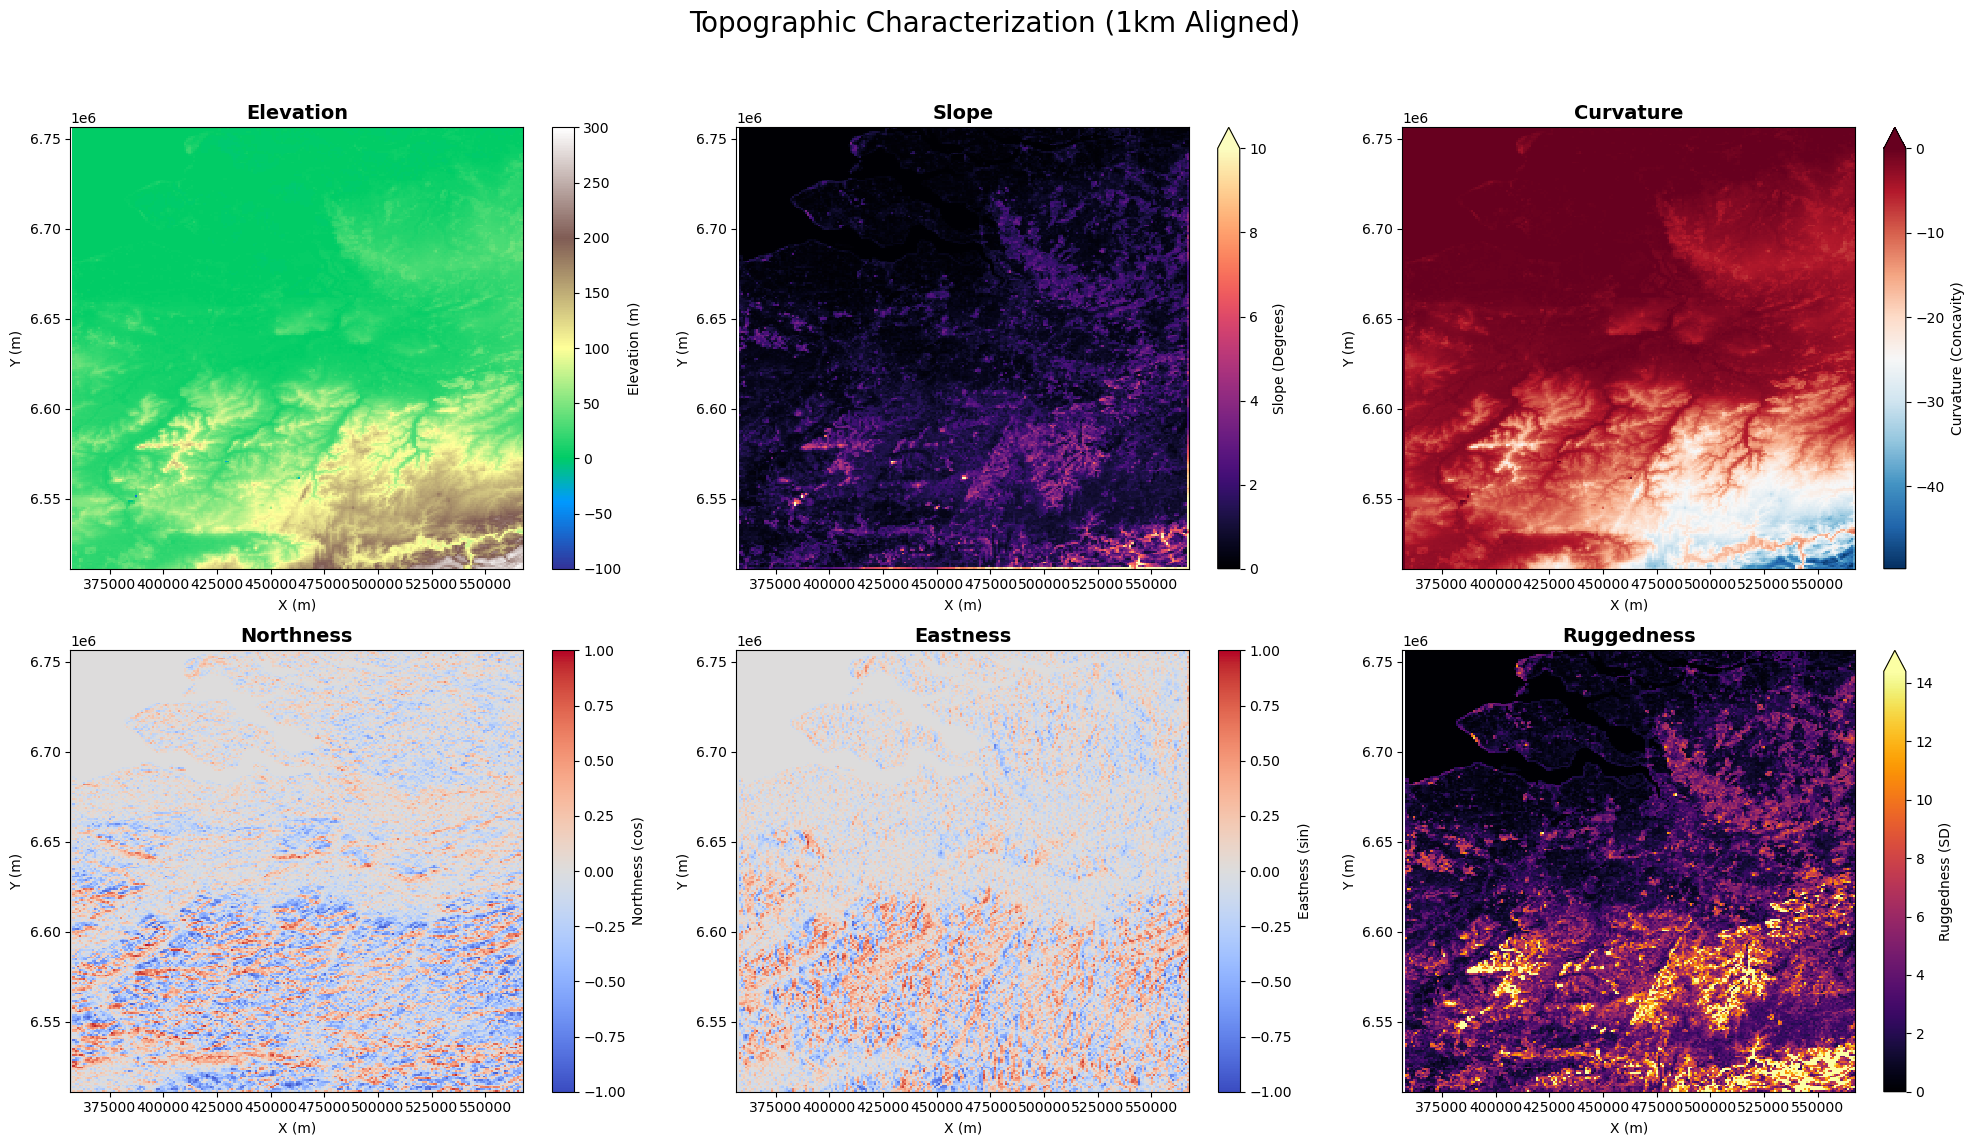

In [15]:
import numpy as np
numeric_vars = [v for v in topo_ds.data_vars if np.issubdtype(topo_ds[v].dtype, np.number)]

# 2. DEFINE CUSTOM SETTINGS
# We map your requested limits and appropriate colormaps to the variables
settings = {
    "elevation":  {"vmin": -100, "vmax": 300, "cmap": "terrain", "label": "Elevation (m)"},
    "slope":      {"vmax": 10,  "cmap": "magma",   "label": "Slope (Degrees)"},
    "curvature":  {"vmax": 0,   "cmap": "RdBu_r",  "label": "Curvature (Concavity)"},
    "northness":  {"vmin": -1,  "vmax": 1, "cmap": "coolwarm", "label": "Northness (cos)"},
    "eastness":   {"vmin": -1,  "vmax": 1, "cmap": "coolwarm", "label": "Eastness (sin)"},
    "ruggedness": {"cmap": "inferno", "robust": True, "label": "Ruggedness (SD)"}
}

# 3. CREATE PLOT
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(20, 12))
axes = axes.flatten()

for i, var in enumerate(numeric_vars):
    if i >= len(axes): break
    
    ax = axes[i]
    config = settings.get(var, {"robust": True, "cmap": "viridis"})
    
    # Extract specific plot arguments from config
    plot_args = {k: v for k, v in config.items() if k != 'label'}
    
    # Render the map
    im = topo_ds[var].plot(
        ax=ax, 
        add_colorbar=True, 
        cbar_kwargs={'label': config.get('label', var)},
        **plot_args
    )
    
    ax.set_title(var.capitalize(), fontsize=14, fontweight='bold')
    ax.set_xlabel("X (m)")
    ax.set_ylabel("Y (m)")

# Final layout cleaning
plt.suptitle("Topographic Characterization (1km Aligned)", fontsize=20, y=0.98)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig("topographic.png")

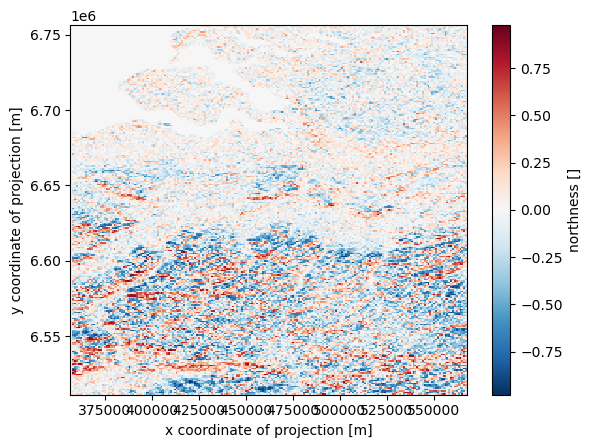

In [29]:
topo_ds["northness"].plot()

In [18]:
import sys
from pathlib import Path

# Add the src directory to sys.path
sys.path.append(str(Path().resolve().parents[1] / "src"))

from datasource.gbif import sql

In [19]:
bbox = sql.bbox2polygon_wkt((3.510132,50.675576,4.795532,51.455718))

occurrenceGridNA_test = sql.generate_query([1311477, 5334357], 
                                       ["month", "year", "speciesKey", "countrycode", "gbifid"], 
                                       "occurrence", 
                                       bbox)

In [20]:
occurrenceGridNA_test

'SELECT "month","year",speciesKey,countrycode,gbifid\n                           ,decimalLatitude, decimalLongitude, COALESCE(coordinateUncertaintyInMeters, 1000) as coordinateUncertaintyInMeters\n                           \n                           \n                            FROM occurrence WHERE GBIF_Within(\'POLYGON ((4.795532 50.675576, 4.795532 51.455718, 3.510132 51.455718, 3.510132 50.675576, 4.795532 50.675576))\', decimalLatitude, decimalLongitude) = TRUE\n                           AND "month" IS NOT NULL AND "year" IS NOT NULL \n                           AND  hasCoordinate = TRUE AND NOT ARRAY_CONTAINS(issue, \'ZERO_COORDINATE\') AND NOT ARRAY_CONTAINS(issue, \'COORDINATE_OUT_OF_RANGE\') AND NOT ARRAY_CONTAINS(issue, \'COORDINATE_INVALID\') AND NOT ARRAY_CONTAINS(issue, \'COUNTRY_COORDINATE_MISMATCH\') \n                           AND taxonKey IN (1311477,5334357) \n                           AND occurrenceStatus IN (\'PRESENT\', \'UNKNOWN\') '